In [37]:
#Version Numbers Used to Generate this Pset:
#seaborn=0.11.2
#scipy==1.8.0
#numpy==1.22.2
#matplotlib==3.5.1

import scipy as sp
from pylab import *
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
import pandas as pd
import seaborn as sns
import collections
from IPython.display import clear_output
import random
import openpyxl
import os 
sns.set_style("ticks")
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklearn.preprocessing import PolynomialFeatures
import pickle

DataTitle="Data_dynamics"

np.random.seed(1)
if not os.path.exists(DataTitle):

   # Create a new directory because it does not exist
   os.makedirs(DataTitle)
   print("The new directory is created!")

mm = 0.1/2.54
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/latex'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['font.size'] = 8
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.4
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.4
mpl.rcParams['ytick.major.width'] = 0.5

plt.rcParams['text.usetex'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [38]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

my_cmap = ListedColormap(['#00429d', '#4771b2', '#73a2c6', '#a5d5d8', '#ffffe0', '#ffbcaf', '#f4777f', '#cf3759', '#93003a'], name="my_cmap")
my_cmap_r = my_cmap.reversed()
mpl.colormaps.register(cmap=my_cmap)
mpl.colormaps.register(cmap=my_cmap_r)

ValueError: A colormap named "my_cmap" is already registered.

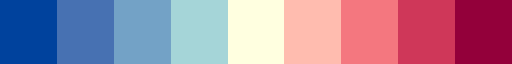

In [3]:
my_cmap

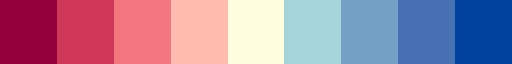

In [4]:
my_cmap_r

In [39]:
def getIDX(data, IDX):
    O = np.flatnonzero([x == IDX for x in data['SampleIDX']])
    return np.array(O)

def getAbundance(Processed_sequences,IDX):
    SampleIdx= np.flatnonzero([x == IDX for x in Processed_sequences['SampleIDX']])
    if not any(SampleIdx):
        return
    else:
        O=Processed_sequences.iloc[SampleIdx].values.tolist()[0][1:]
        return O

def getAbundance_fromList(Processed_sequences,IDX_list):
    IDX_list_=np.squeeze([np.where(Processed_sequences['SampleIDX']==x) for x in IDX_list])
    return (np.array(Processed_sequences.iloc[IDX_list_].values)[:,1:]).astype(float)

def Community_PermutateList_simulation(I,S):
    global Metadata,exception_list
    sample_num=100
    O=(3*(I-1)+(S-1))*100+np.arange(0,100)
    return O

def CommunityPermutate(Timepoint, CommunityOrigin, Medium, CoalescenceType):
    global Metadata
    idx = np.where((Metadata['Timepoint'] == Timepoint) &
                   (Metadata['CommunityOrigin'] == CommunityOrigin) &
                   (Metadata['Medium'] == Medium) &
                   (Metadata['CoalescenceType'] == CoalescenceType))[0]
    O = np.concatenate(Metadata['SampleIDX'][idx])
    return O

def CommunityPermutate_withSpeciesPoolsize(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num):
    global Metadata,exception_list
    idx = (Metadata['Timepoint'] == Timepoint) & \
          (Metadata['CommunityOrigin'] == CommunityOrigin) & \
          (Metadata['Medium'] == Medium) & \
          (Metadata['CoalescenceType'] == CoalescenceType)

    communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
    if CoalescenceType == 'S':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 9)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
    elif CoalescenceType == 'C':
        if species_pool_num == 6:
            idx = idx & (communityIDX <= 14)
        elif species_pool_num == 12:
            idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
        elif species_pool_num == 24:
            idx = idx & ((communityIDX > 41) & (communityIDX <= 47))

    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def Community_PermutateList(Timepoint, CommunityOrigin, Medium, CoalescenceType, species_pool_num=0, Replicate=-1):
    global Metadata,exception_list
    
    if Replicate==-1:
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType)
    elif Replicate == 1 or Replicate == 2 : 
        idx = (Metadata['Timepoint'] == Timepoint) & \
              (Metadata['CommunityOrigin'] == CommunityOrigin) & \
              (Metadata['Medium'] == Medium) & \
              (Metadata['CoalescenceType'] == CoalescenceType) & \
              (Metadata['Replicate'] == Replicate)
    else : 
        raise ValueError("Invalid input")

    
    if CommunityOrigin=='S':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        if CoalescenceType == 'S':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 9)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 9) & (communityIDX <= 18))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 18) & (communityIDX <= 30))
            elif species_pool_num ==0:
                idx = idx
        elif CoalescenceType == 'C':
            if species_pool_num == 6:
                idx = idx & (communityIDX <= 14)
            elif species_pool_num == 12:
                idx = idx & ((communityIDX > 14) & (communityIDX <= 41))
            elif species_pool_num == 24:
                idx = idx & ((communityIDX > 41) & (communityIDX <= 47))
            elif species_pool_num ==0:
                idx = idx
    elif CommunityOrigin=='N':
        communityIDX = np.array([int(x) for x in Metadata['CommunityIDX']])
        
    O = Metadata['SampleIDX'][idx]
    O = list(set(O) - set(exception_list))
    return O

def getCommunities(Communities_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Communities_data['SampleIDX']==x) for x in IDX_list])
    return (Communities_data.iloc[IDX_list_])

def getCoalescence(Coalescence_data,IDX_list):
    IDX_list_=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])#IDX_list_
    return (Coalescence_data.iloc[IDX_list_])

Coalescence_data_synthetic_path ="../../Analyzed/processed_CoalescenceEvent_synthetic.xlsx"
Communities_data_synthetic_path ="../../Analyzed/processed_Communities_synthetic.xlsx"
Coalescence_data_natural_path ="../../Analyzed/processed_CoalescenceEvent_natural.xlsx"
Communities_data_natural_path ="../../Analyzed/processed_Communities_natural.xlsx"
Coalescence_recipe_path="../../Postprocessed/CoalescenceRecipe.xlsx"
Meta_data_path="../../Postprocessed/Metadata.xlsx"
Processed_sequences_synthetic_path="../../Postprocessed/processed_Sequences_synthetic.xlsx"
Processed_sequences_natural_path="../../Postprocessed/processed_Sequences_natural.xlsx"
Coalescence_data_sim_path="../../Analyzed/processed_CoalescenceEvent_simulation_uniform.xlsx"
#Communities_data_sim_path="Analyzed/processed_Communities_simulation_uniform.xlsx"

Coalescence_data=pd.concat([pd.read_excel(Coalescence_data_synthetic_path),pd.read_excel(Coalescence_data_natural_path)])
Communities_data=pd.concat([pd.read_excel(Communities_data_synthetic_path),pd.read_excel(Communities_data_natural_path)])
Coalescence_data_sim=pd.read_excel(Coalescence_data_sim_path)
#Communities_data_sim=pd.read_excel(Communities_data_sim_path)

Coalescence_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=0)
Coalescence_natural_recipe=pd.read_excel(Coalescence_recipe_path,sheet_name=1)
Metadata=pd.read_excel(Meta_data_path)
Processed_sequences_synthetic=pd.read_excel(Processed_sequences_synthetic_path)
Processed_sequences_natural=pd.read_excel(Processed_sequences_natural_path)

exception_list=['P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12']+['P8-91'] + ['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] + ['P5-47', 'P5-50'] + ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57']
#'P4-02','P4-03','P4-23','P4-24','P7-97', 'P8-12' : These cases are for no reads in coalescence result
# 'P8-91' : no file
#['P5-73', 'P5-69','P5-64','P5-61','P5-59', 'P5-56'] : MN E7 is missing
# 'P6-67' : is too low reads( 500)
# 'P5-47', 'P5-50' : MN24 CC, too much unwanted ASVs(maybe due to wrong labeling)
# ['P5-39', 'P5-87', 'P5-54', 'P6-02', 'P6-47', 'P6-74', 'P6-57'] : ASV not in sub 2> 0.3

I = [0.33, 0.66, 0.99]
species_pools = [6, 12, 24]
sample_num=100
Syn_Simulation_IDX = {
    "I1_S1": Community_PermutateList_simulation(1,1),
    "I1_S2": Community_PermutateList_simulation(1,2),
    "I1_S3": Community_PermutateList_simulation(1,3),
    "I2_S1": Community_PermutateList_simulation(2,1),
    "I2_S2": Community_PermutateList_simulation(2,2),
    "I2_S3": Community_PermutateList_simulation(2,3),
    "I3_S1": Community_PermutateList_simulation(3,1),
    "I3_S2": Community_PermutateList_simulation(3,2),
    "I3_S3": Community_PermutateList_simulation(3,3),
}
mediums_pools = ["LN", "MN", "HN"]
species_pools = [6, 12, 24]
Syn_Coal_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "C", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "C", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "C", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "C", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "C", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "C", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "C", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "C", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "C", 24)
}
Syn_Sub_IDX = {
    "LN_6": Community_PermutateList("F", "S", "L", "S", 6),
    "LN_12": Community_PermutateList("F", "S", "L", "S", 12),
    "LN_24": Community_PermutateList("F", "S", "L", "S", 24),
    "MN_6": Community_PermutateList("F", "S", "M", "S", 6),
    "MN_12": Community_PermutateList("F", "S", "M", "S", 12),
    "MN_24": Community_PermutateList("F", "S", "M", "S", 24),
    "HN_6": Community_PermutateList("F", "S", "H", "S", 6),
    "HN_12": Community_PermutateList("F", "S", "H", "S", 12),
    "HN_24": Community_PermutateList("F", "S", "H", "S", 24)
}
Nat_Coal_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "C"),
    "MN": Community_PermutateList("F", "N", "M", "C"),
    "HN": Community_PermutateList("F", "N", "H", "C")
}
Nat_Sub_IDX = {
    "LN": Community_PermutateList("F", "N", "L", "S"),
    "MN": Community_PermutateList("F", "N", "M", "S"),
    "HN": Community_PermutateList("F", "N", "H", "S")
}




In [6]:
from InitializeSpeciesPool import *
from LV import *
from VariousMetrics import *

########################################################
########################################################
# Fig 3-1
########################################################
########################################################

##~~~~~~~~~~~~~~ This figure is cartoon ~~~~~~~~~~~~~~##

In [40]:
    Variable2plot='Assymetricity_BC_5'
    IDX_list = Syn_Coal_IDX["LN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data1=data
    
    IDX_list = Syn_Coal_IDX["MN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data2=data
    
    IDX_list = Syn_Coal_IDX["HN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data3 = data

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


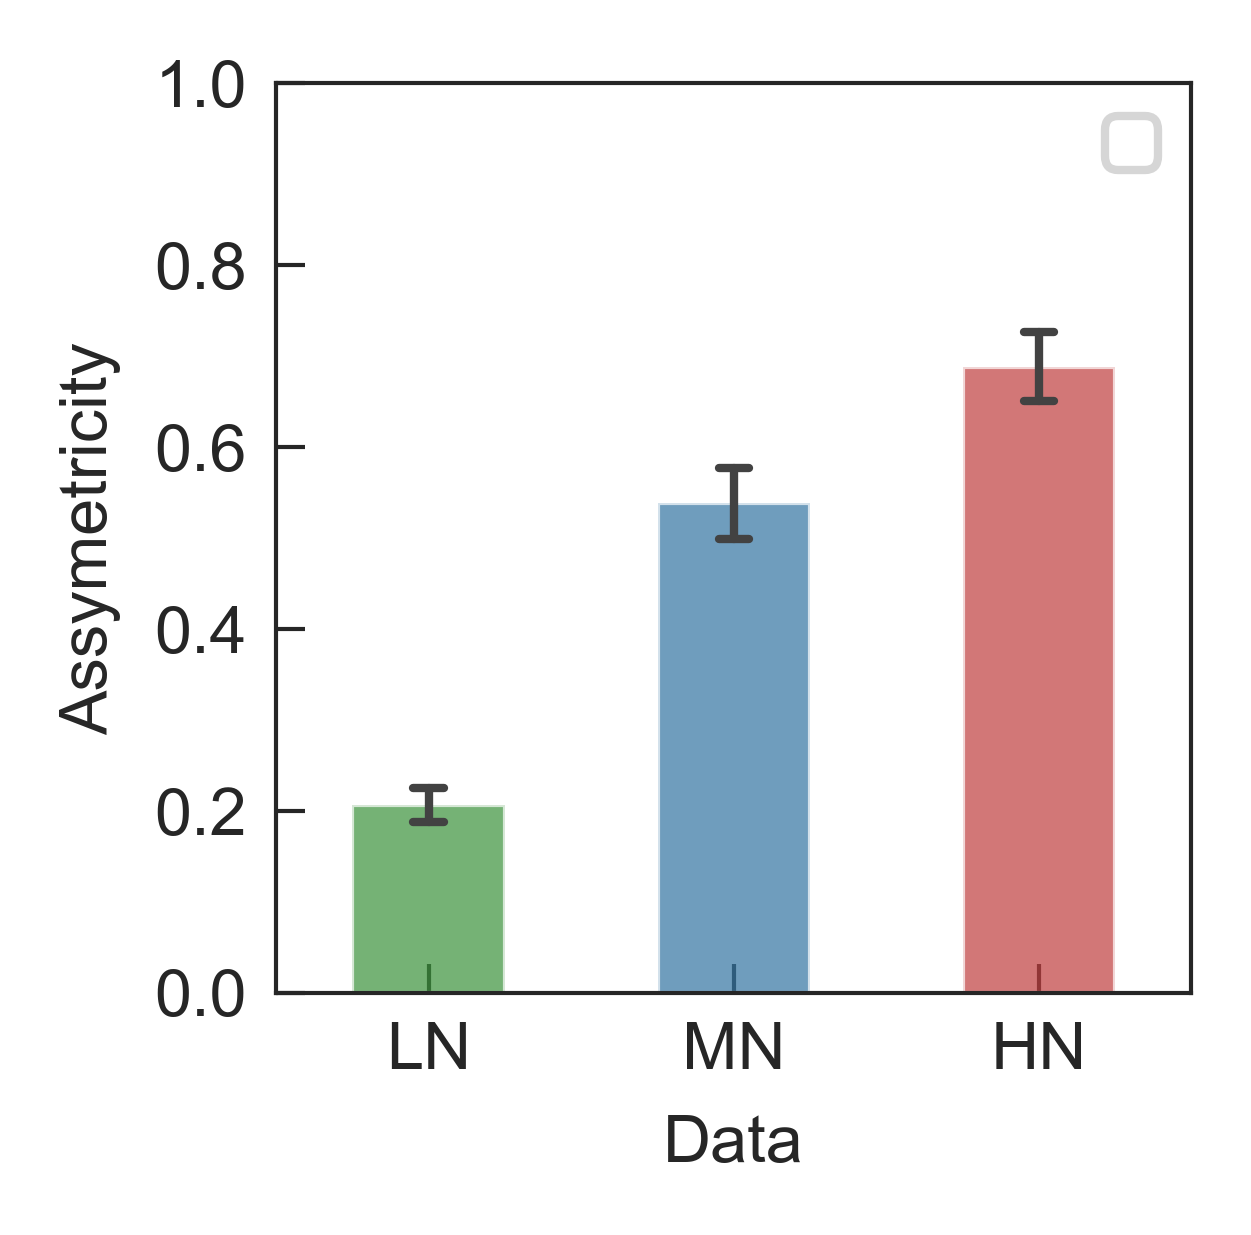

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


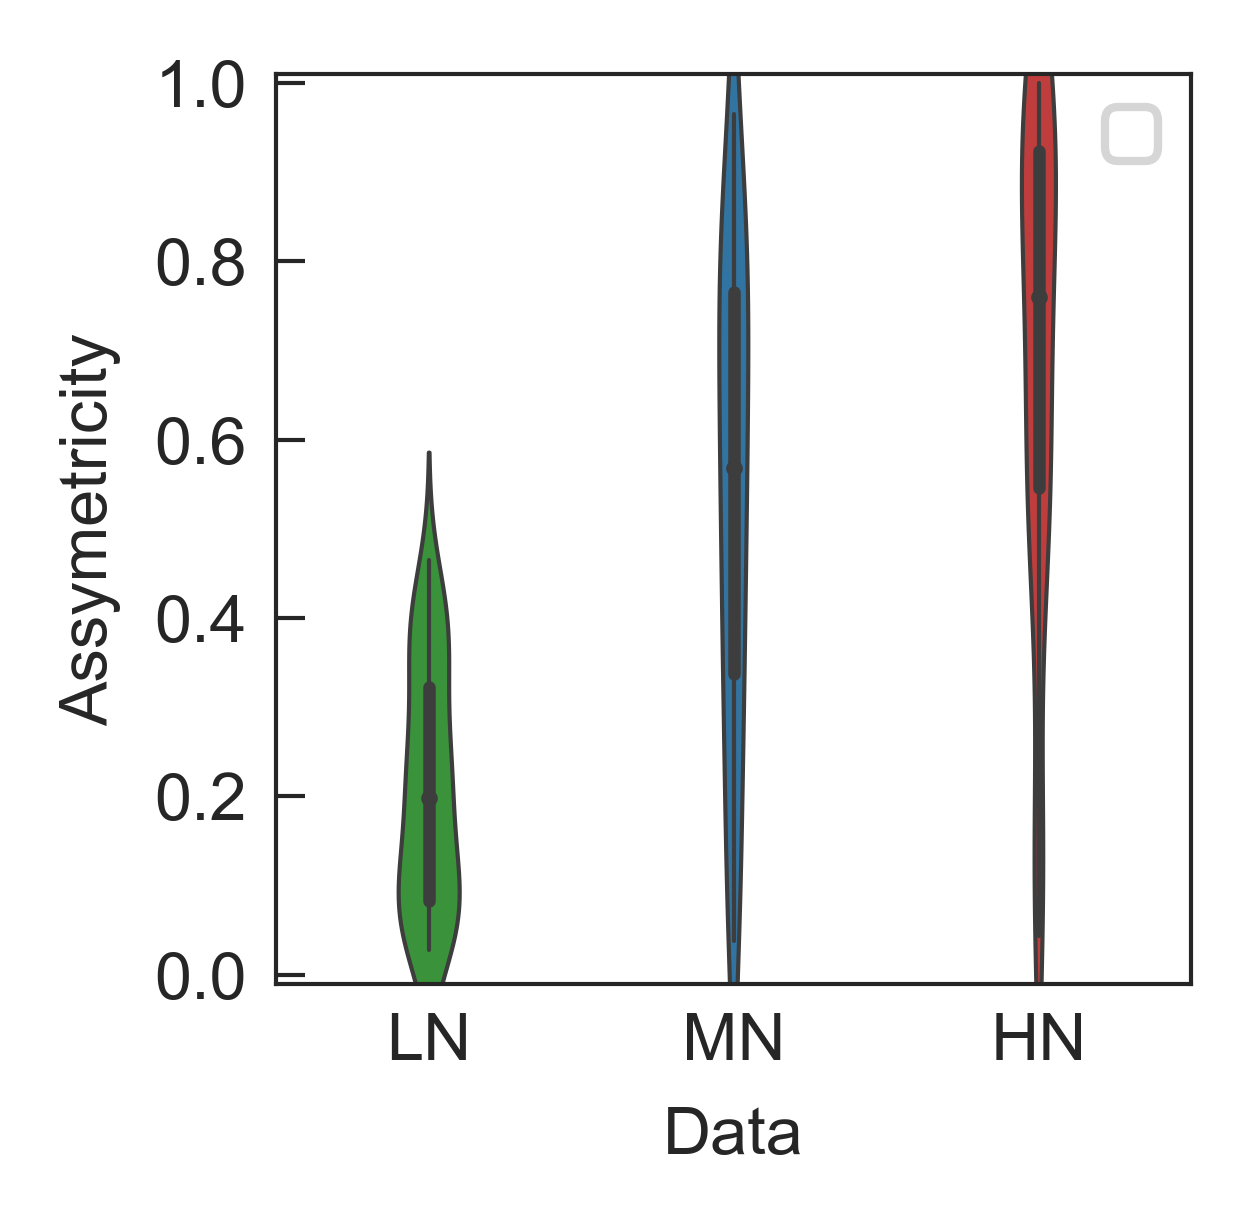

In [43]:
## Coal Figure 2. Plot every variable - swarm&box

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
Variable2plot_list=[
       'Assymetricity_BC_5']


for Variable2plot in Variable2plot_list:
    Name2show = Variable2plot
    
    IDX_list = Syn_Coal_IDX["LN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data1=data
    
    IDX_list = Syn_Coal_IDX["MN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data2=data
    
    IDX_list = Syn_Coal_IDX["HN_12"]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data3 = data

    
    combined_data = np.concatenate([data1, data2, data3])
    labels = ['LN'] * len(data1) + ['MN'] * len(data2) + ['HN'] * len(data3)
    df = pd.DataFrame({'Value': combined_data, 'Data': labels})

    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(50*mm,50*mm),facecolor='w', edgecolor='k')
    #sns.boxplot(x='Data', y='Value', data=df, order=['LN', 'MN', 'HN'], width=0.2, boxprops=dict(alpha=.7),  linewidth=.5, palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})
    sns.barplot(x='Data', y='Value', data=df,  errorbar=('se'), order=['LN', 'MN', 'HN'], width=0.5, alpha=0.7, capsize=.1, errwidth=1,  linewidth=.5, palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})
    plt.ylabel('Assymetricity')
    plt.ylim(0, 1.0)
    
    plt.legend()
    plt.show()
    f.savefig('Figure/Fig_3-1_NutrientVarying_BOXplot_'+str(Variable2plot)+'.svg', bbox_inches='tight')

    f, ax = plt.subplots(1, figsize=(50*mm,50*mm),facecolor='w', edgecolor='k')
    sns.violinplot(x='Data', y='Value', data=df, order=['LN', 'MN', 'HN'], width=0.2, boxprops=dict(alpha=.7),  linewidth=.5,   palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})
    plt.ylabel('Assymetricity')
    plt.ylim(-0.01, 1.01)
    plt.legend()
    plt.show()
    f.savefig('Figure/Fig_3-1_NutrientVarying_Violinplot_'+str(Variable2plot)+'.svg', bbox_inches='tight')
    
    


#AllAbudnaces=getAbundance(Metadata['SampleIDX'])

T-statistic: -3.9261
P-value: 0.0001485814360388908184074097107441048137843608856201171875000000000000000000000000000000000000000000
T-statistic: 3.4388
P-value: 0.0010123759088299028648799682272851896414067596197128295898437500000000000000000000000000000000000000
T-statistic: 2.7456
P-value: 0.0076715350966202354096590276810729847056791186332702636718750000000000000000000000000000000000000000


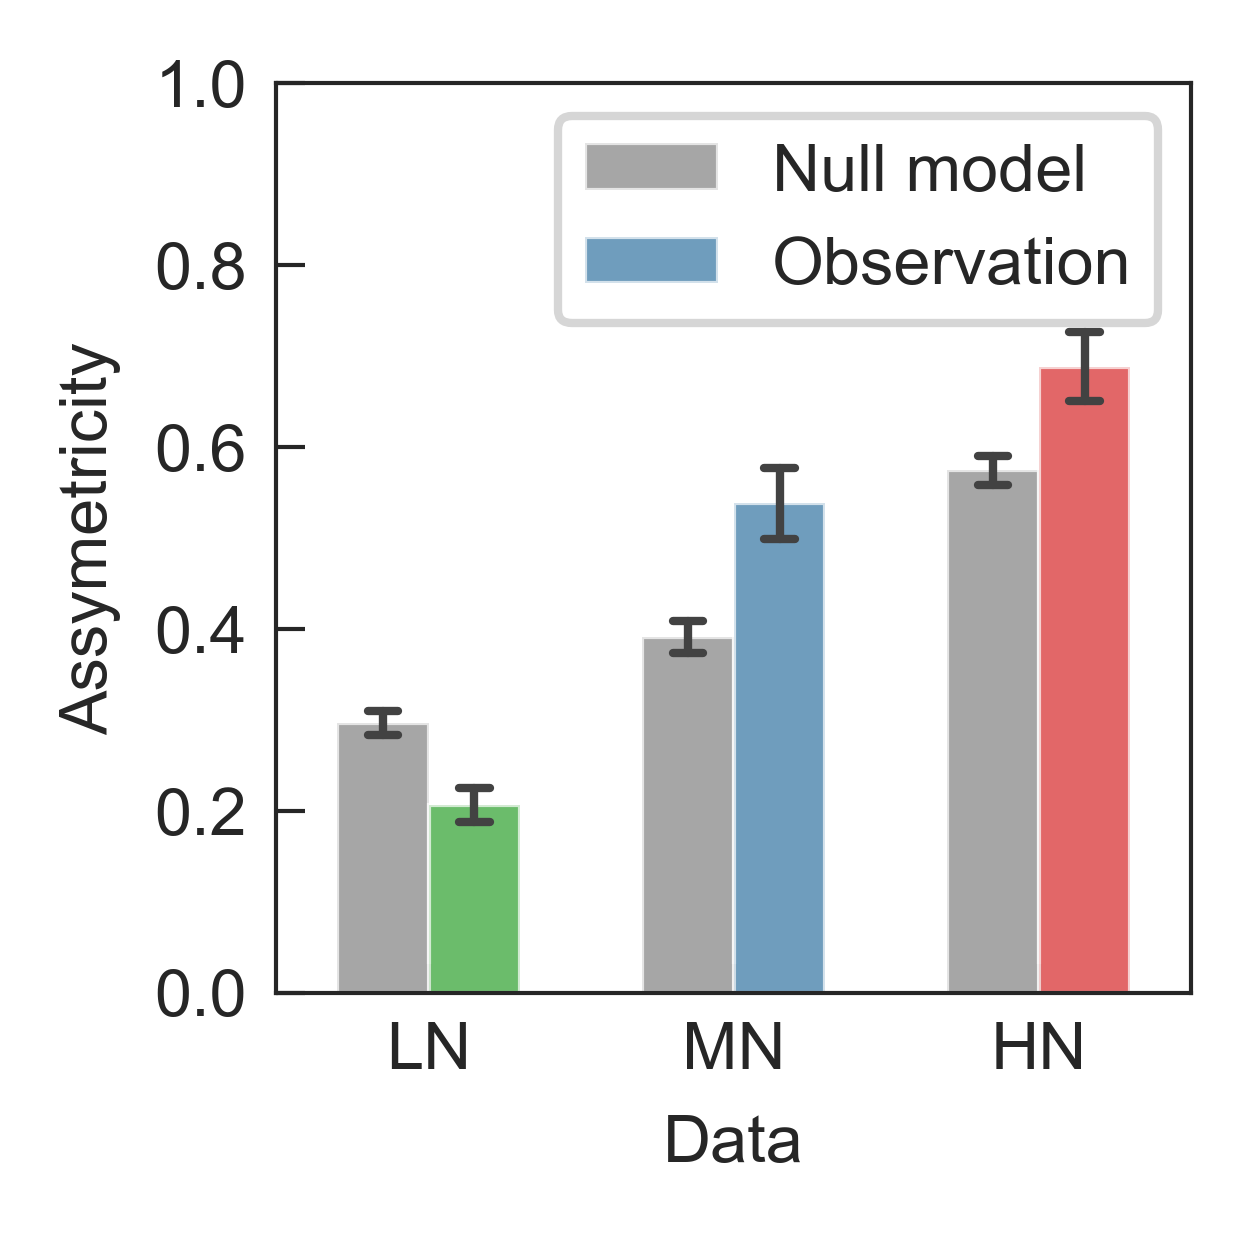

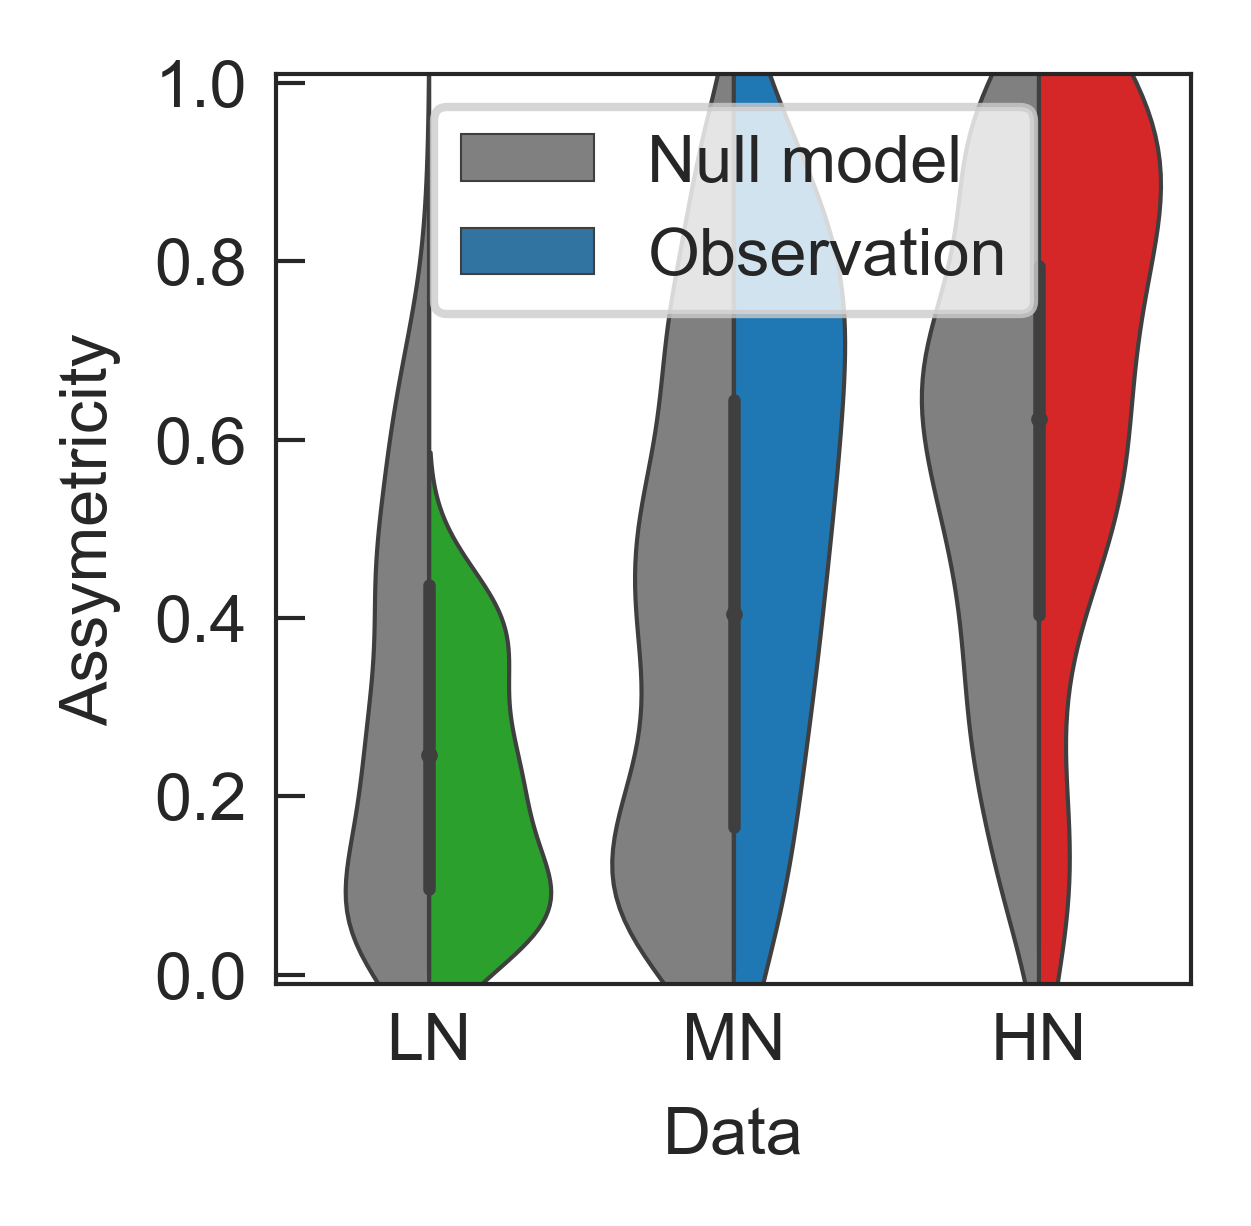

In [42]:
## Coal Figure 2. Plot every variable - swarm&box
from scipy.stats import ttest_ind
from matplotlib.collections import PolyCollection
from matplotlib.colors import to_rgb

typeofplot='swarmpoint' # choose among 'swarmbox', 'swarmpoint'
Variable2plot_list=[
       'Assymetricity_BC_5']
N_simul=5

for Variable2plot in Variable2plot_list:
    Name2show = Variable2plot
    
    degList=np.zeros(43)
    type_name='LN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data1=data
    if True: 
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
        IDX_list = Syn_Coal_IDX[type_name]
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            for _ in range(N_simul):
                c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
                c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
                c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
                c_1=c_1*(c_1>1e-4)
                c_2=c_2*(c_2>1e-4)
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))

                similarity=(F1)/(F1+F2)
                data_null_model.append(abs(2*similarity-1))
        x=abs(data)
        y=abs(np.array(data_null_model))
        t_stat, p_value = ttest_ind(x,y,equal_var=False)

        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.100f}")
    data1_null = np.array(data_null_model)
    
    type_name='MN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data2=data 
    if True: 
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
        IDX_list = Syn_Coal_IDX[type_name]
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            for _ in range(N_simul):
                c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
                c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
                c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
                c_1=c_1*(c_1>1e-4)
                c_2=c_2*(c_2>1e-4)
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))

                similarity=(F1)/(F1+F2)
                data_null_model.append(abs(2*similarity-1))
        x=abs(data)
        y=abs(np.array(data_null_model))
        t_stat, p_value = ttest_ind(x,y,equal_var=False)

        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.100f}")
    data2_null = np.array(data_null_model)
    
    type_name='HN_12'
    
    IDX_list = Syn_Coal_IDX[type_name]
    data = getCoalescence(Coalescence_data,IDX_list)
    data = data[Variable2plot]
    data3=data
    
    if True: 
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])
        IDX_list = Syn_Coal_IDX[type_name]
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_1=Coalescence_data.iloc[idx]["SampleIDX_Sub1"].tolist()
        idx_1=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_1])
        idx=np.squeeze([np.where(Coalescence_data['SampleIDX']==x) for x in IDX_list])
        idx_2=Coalescence_data.iloc[idx]["SampleIDX_Sub2"].tolist()
        idx_2=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in idx_2])
        idx=np.squeeze([np.where(Processed_sequences_synthetic['SampleIDX']==x) for x in IDX_list])

        species_num=len(degList)
        data_null_model=[]
        for i in range(len(idx)):
            for _ in range(N_simul):
                c_mix=Processed_sequences_synthetic.iloc[idx[i]].values.tolist()[1:]
                c_1=np.array(Processed_sequences_synthetic.iloc[idx_1[i]].values.tolist()[1:])
                c_2=np.array(Processed_sequences_synthetic.iloc[idx_2[i]].values.tolist()[1:])
                c_1=c_1*(c_1>1e-4)
                c_2=c_2*(c_2>1e-4)
                mix_label=(np.random.rand(species_num)>0.5).astype(int)
                moc_c1=(mix_label)*c_1+(1-mix_label)*c_2
                moc_c2=(1-mix_label)*c_1+(mix_label)*c_2
                moc_c1=moc_c1/(np.sum(moc_c1)+1e-9)
                moc_c2=moc_c2/(np.sum(moc_c2)+1e-9)

                F1=np.sum(np.minimum(moc_c1,c_mix))
                F2=np.sum(np.minimum(moc_c2,c_mix))

                similarity=(F1)/(F1+F2)
                data_null_model.append(abs(2*similarity-1))
            # Perform the t-test
        x=abs(data)
        y=abs(np.array(data_null_model))
        t_stat, p_value = ttest_ind(x,y,equal_var=False)

        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.100f}")
    data3_null = np.array(data_null_model)


    
    combined_data = np.concatenate([data1, data2, data3, data1_null, data2_null,data3_null])
    labels = ['LN'] * len(data1) + ['MN'] * len(data2) + ['HN'] * len(data3)+['LN'] * len(data1_null) + ['MN'] * len(data2_null) + ['HN'] * len(data3_null)
    Origin=['Observation'] * len(data1) + ['Observation'] * len(data2) + ['Observation'] * len(data3)+['Null model'] * len(data1_null) + ['Null model'] * len(data2_null) + ['Null model'] * len(data3_null)
    df = pd.DataFrame({'Value': combined_data, 'Data': labels, 'Origin': Origin})

    # Convert the data into a DataFrame
    f, ax = plt.subplots(1, figsize=(50*mm,50*mm),facecolor='w', edgecolor='k')
    #sns.boxplot(x='Data', y='Value', data=df, order=['LN_null','LN','MN_null','MN', 'HN_null', 'HN'], width=0.2, boxprops=dict(alpha=1),  linewidth=.5, palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette()[0], "HN": sns.color_palette()[3], "LN_null": sns.color_palette()[2], "MN_null": sns.color_palette()[0], "HN_null": sns.color_palette()[3]})
    sns.barplot(x='Data', y='Value', data=df, hue='Origin', hue_order=['Null model','Observation'], errorbar=('se'),width=0.6, alpha=0.7, capsize=.1, errwidth=1, linewidth=.5, palette = {'Observation': sns.color_palette("tab10")[0], "Null model": 'gray'})
    #sns.barplot(x='Data', y='Value', data=df,  errorbar=('se'), order=['LN', 'MN', 'HN'], width=0.5, alpha=0.7, capsize=.1, errwidth=1,  linewidth=.5, palette = {"LN": sns.color_palette("tab10")[2], "MN": sns.color_palette("tab10")[0], "HN": sns.color_palette("tab10")[3]})

    plt.legend()

    mybox = ax.patches[3]
    # Change the appearance of that box
    mybox.set_facecolor(sns.color_palette("tab10")[2])
    
    mybox = ax.patches[5]
    # Change the appearance of that box
    mybox.set_facecolor(sns.color_palette("tab10")[3])
    
    plt.ylabel('Assymetricity')
    plt.ylim(0, 1)
    plt.show()
    f.savefig('Figure/Fig_3-1_NutrientVarying_BOXplot_'+str(Variable2plot)+'.svg', bbox_inches='tight')

    
    f, ax = plt.subplots(1, figsize=(50*mm,50*mm),facecolor='w', edgecolor='k')
    sns.violinplot(x='Data', y='Value', data=df, hue='Origin', hue_order=['Null model','Observation'], split=True, width=0.8, boxprops=dict(alpha=1),  linewidth=.5, palette = {'Observation': sns.color_palette("tab10")[0], "Null model": 'gray'})
    #sns.violinplot(x='Data', y='Value', data=df, hue='Origin', hue_order=['Null model','Observation'], split=True, width=0.4, boxprops=dict(alpha=1),  linewidth=.5, palette = ['r', 'g','b'])
    colors = sns.color_palette('Set2')
    plt.ylabel('Assymetricity')
    for ind, violin in enumerate(ax.findobj(PolyCollection)):
        order=[2,0,3]
        rgb = sns.color_palette("tab10")[order[ind//2]]
        if ind % 2 == 0:
            rgb='grey'
            #rgb = 0.5 + 0.5 * np.array(rgb)  # make whiter
        violin.set_facecolor(rgb)

    
    plt.ylim(-0.01, 1.01)
    plt.legend()
    plt.show()
    f.savefig('Figure/Fig_3-1_NutrientVarying_Violinplot_'+str(Variable2plot)+'_wNullmodel.svg', bbox_inches='tight')
    
    


#AllAbudnaces=getAbundance(Metadata['SampleIDX'])

In [ ]:
ax.patches